In [1]:
# ============================================
# Step 1: Imports and device setup
# ============================================
import os
from pathlib import Path
from time import time
from typing import Tuple, Dict

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, Image
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import xarray as xr

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())


# ============================================
# Step 2: Load and preprocess data
# ============================================

# ============================================
# Step 1: Imports and device setup
# ============================================
import os
from pathlib import Path
from time import time
from typing import Tuple, Dict

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, Image
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import xarray as xr

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())


# ============================================
# Step 2: Load and preprocess data
# ============================================

file_path = "output-tracer-release-rand-wind-365-_2025-11-18.nc"
ds = xr.open_dataset(file_path, chunks={'time': 10})

# Extract and align variables on (time, y, x)
u = ds['u'].squeeze('zC').rename({'xF': 'x', 'yC': 'y'})  # (time, y, x)
v = ds['v'].squeeze('zC').rename({'xC': 'x', 'yF': 'y'})  # (time, y, x)
c = ds['c'].squeeze('zC').rename({'xC': 'x', 'yC': 'y'})  # (time, y, x)

# Merge into single Dataset and fill NaNs
ds_merge = xr.merge([
    u.to_dataset(name='u'),
    v.to_dataset(name='v'),
    c.to_dataset(name='c'),
]).fillna(0.0)

# Input at t, target at t+1 (hourly snapshots)
ds_input  = ds_merge.isel(time=slice(0, -1))    # t0 ... t_{N-2}
ds_target = ds_merge.isel(time=slice(1, None))  # t1 ... t_{N-1}

# Grid spacing in meters
x = ds["xC"].values
y = ds["yC"].values
dx = float(x[1] - x[0])
dy = float(y[1] - y[0])
print("dx, dy (m):", dx, dy)

# --------------------------------------------
# Helper: convert xarray -> torch tensor
# --------------------------------------------
def to_tensor(ds_var, var_list):
    """
    ds_var: xarray.Dataset with dims (time, y, x)
    var_list: list of variable names to stack
    returns tensor of shape (time, n_vars, y, x)
    """
    arr = ds_var[var_list].to_array().values  # (n_vars, time, y, x)
    t = torch.tensor(arr, dtype=torch.float32)  # (n_vars, time, y, x)
    return t.permute(1, 0, 2, 3).to(device)    # (time, n_vars, y, x)

forcing_vars    = ['u', 'v']
prognostic_vars = ['c']
input_vars      = forcing_vars + prognostic_vars
output_vars     = prognostic_vars

forcing_tensor    = to_tensor(ds_input, forcing_vars)      # (Nt-1, 2, H, W)
prognostic_tensor = to_tensor(ds_input, prognostic_vars)   # (Nt-1, 1, H, W)
target_tensor     = to_tensor(ds_target, output_vars)      # (Nt-1, 1, H, W)

print("Forcing shape:",    forcing_tensor.shape)
print("Prognostic shape:", prognostic_tensor.shape)
print("Target shape:",     target_tensor.shape)

# --------------------------------------------
# Normalization
# --------------------------------------------
def normalize(tensor):
    mean = tensor.mean()
    std  = tensor.std()
    return (tensor - mean) / std, mean, std

forcing_tensor, f_mean, f_std    = normalize(forcing_tensor)
prognostic_tensor, p_mean, p_std = normalize(prognostic_tensor)
target_tensor = (target_tensor - p_mean) / p_std  # normalize with same stats

print("NaNs in forcing:",  torch.isnan(forcing_tensor).sum().item())
print("NaNs in target:",   torch.isnan(target_tensor).sum().item())

# --------------------------------------------
# Train / val / test split (along time axis)
# --------------------------------------------
Nt = forcing_tensor.shape[0]
n_train = int(0.7 * Nt)
n_val   = int(0.85 * Nt)
n_test  = Nt - n_val


forcing_train    = forcing_tensor[:n_train]
prognostic_train = prognostic_tensor[:n_train]
target_train     = target_tensor[:n_train]

forcing_val    = forcing_tensor[n_train:n_val]
prognostic_val = prognostic_tensor[n_train:n_val]
target_val     = target_tensor[n_train:n_val]

forcing_test    = forcing_tensor[n_val:]
prognostic_test = prognostic_tensor[n_val:]
target_test     = target_tensor[n_val:]

print(f"Train/Val/Test sizes: {n_train}, {n_val-n_train}, {n_test}")



file_path = "output-tracer-release-rand-wind-365-_2025-11-18.nc"
ds = xr.open_dataset(file_path, chunks={'time': 10})

# Extract and align variables on (time, y, x)
u = ds['u'].squeeze('zC').rename({'xF': 'x', 'yC': 'y'})  # (time, y, x)
v = ds['v'].squeeze('zC').rename({'xC': 'x', 'yF': 'y'})  # (time, y, x)
c = ds['c'].squeeze('zC').rename({'xC': 'x', 'yC': 'y'})  # (time, y, x)

# Merge into single Dataset and fill NaNs
ds_merge = xr.merge([
    u.to_dataset(name='u'),
    v.to_dataset(name='v'),
    c.to_dataset(name='c'),
]).fillna(0.0)

# Input at t, target at t+1 (hourly snapshots)
ds_input  = ds_merge.isel(time=slice(0, -1))    # t0 ... t_{N-2}
ds_target = ds_merge.isel(time=slice(1, None))  # t1 ... t_{N-1}

# Grid spacing in meters
x = ds["xC"].values
y = ds["yC"].values
dx = float(x[1] - x[0])
dy = float(y[1] - y[0])
print("dx, dy (m):", dx, dy)

# --------------------------------------------
# Helper: convert xarray -> torch tensor
# --------------------------------------------
def to_tensor(ds_var, var_list):
    """
    ds_var: xarray.Dataset with dims (time, y, x)
    var_list: list of variable names to stack
    returns tensor of shape (time, n_vars, y, x)
    """
    arr = ds_var[var_list].to_array().values  # (n_vars, time, y, x)
    t = torch.tensor(arr, dtype=torch.float32)  # (n_vars, time, y, x)
    return t.permute(1, 0, 2, 3).to(device)    # (time, n_vars, y, x)

forcing_vars    = ['u', 'v']
prognostic_vars = ['c']
input_vars      = forcing_vars + prognostic_vars
output_vars     = prognostic_vars

forcing_tensor    = to_tensor(ds_input, forcing_vars)      # (Nt-1, 2, H, W)
prognostic_tensor = to_tensor(ds_input, prognostic_vars)   # (Nt-1, 1, H, W)
target_tensor     = to_tensor(ds_target, output_vars)      # (Nt-1, 1, H, W)

print("Forcing shape:",    forcing_tensor.shape)
print("Prognostic shape:", prognostic_tensor.shape)
print("Target shape:",     target_tensor.shape)

# --------------------------------------------
# Normalization
# --------------------------------------------
def normalize(tensor):
    mean = tensor.mean()
    std  = tensor.std()
    return (tensor - mean) / std, mean, std

forcing_tensor, f_mean, f_std    = normalize(forcing_tensor)
prognostic_tensor, p_mean, p_std = normalize(prognostic_tensor)
target_tensor = (target_tensor - p_mean) / p_std  # normalize with same stats

print("NaNs in forcing:",  torch.isnan(forcing_tensor).sum().item())
print("NaNs in target:",   torch.isnan(target_tensor).sum().item())

# --------------------------------------------
# Train / val / test split (along time axis)
# --------------------------------------------
Nt = forcing_tensor.shape[0]
n_train = int(0.7 * Nt)
n_val   = int(0.85 * Nt)
n_test  = Nt - n_val


forcing_train    = forcing_tensor[:n_train]
prognostic_train = prognostic_tensor[:n_train]
target_train     = target_tensor[:n_train]

forcing_val    = forcing_tensor[n_train:n_val]
prognostic_val = prognostic_tensor[n_train:n_val]
target_val     = target_tensor[n_train:n_val]

forcing_test    = forcing_tensor[n_val:]
prognostic_test = prognostic_tensor[n_val:]
target_test     = target_tensor[n_val:]

print(f"Train/Val/Test sizes: {n_train}, {n_val-n_train}, {n_test}")




Using device: cuda
Torch version: 2.7.1+cu118
CUDA version: 11.8
CUDA available: True
Using device: cuda
Torch version: 2.7.1+cu118
CUDA version: 11.8
CUDA available: True


/tmp/ipykernel_93601/3226046614.py:68: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file_path, chunks={'time': 10})


dx, dy (m): 1000.0 1000.0
Forcing shape: torch.Size([8760, 2, 200, 200])
Prognostic shape: torch.Size([8760, 1, 200, 200])
Target shape: torch.Size([8760, 1, 200, 200])
NaNs in forcing: 0
NaNs in target: 0
Train/Val/Test sizes: 6132, 1314, 1314


/tmp/ipykernel_93601/3226046614.py:160: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file_path, chunks={'time': 10})


dx, dy (m): 1000.0 1000.0
Forcing shape: torch.Size([8760, 2, 200, 200])
Prognostic shape: torch.Size([8760, 1, 200, 200])
Target shape: torch.Size([8760, 1, 200, 200])
NaNs in forcing: 0
NaNs in target: 0
Train/Val/Test sizes: 6132, 1314, 1314


In [2]:
# ============================================
# Step 3: Physics loss
# ============================================
def compute_physics_loss(forcing, prognostic, model_output, dx, dy, D=0.0):
    """
    Compute PDE residual from 2D advection–diffusion equation.
    All inputs: (batch, 1 or 2, H, W) on normalized fields.
    """
    u = forcing[:, 0]  # (B, H, W)
    v = forcing[:, 1]  # (B, H, W)
    c_t   = prognostic[:, 0]     # at time t
    c_tp1 = model_output[:, 0]   # predicted at t+1

    # time step in "1 timestep" units (consistent with training)
    dt = 1.0

    dc_dt = (c_tp1 - c_t) / dt

    # central differences with periodic boundary in x,y
    dc_dx = (torch.roll(c_t, -1, dims=2) - torch.roll(c_t, 1, dims=2)) / (2 * dx)
    dc_dy = (torch.roll(c_t, -1, dims=1) - torch.roll(c_t, 1, dims=1)) / (2 * dy)

    advection = u * dc_dx + v * dc_dy

    if D > 0:
        d2c_dx2 = (torch.roll(c_t, -1, 2) - 2 * c_t + torch.roll(c_t, 1, 2)) / (dx ** 2)
        d2c_dy2 = (torch.roll(c_t, -1, 1) - 2 * c_t + torch.roll(c_t, 1, 1)) / (dy ** 2)
        diffusion = D * (d2c_dx2 + d2c_dy2)
    else:
        diffusion = 0.0

    residual = dc_dt + advection - diffusion
    return torch.mean(residual ** 2)

def compute_mass_loss(model_output, target, p_mean, p_std, dx, dy, 
                      cell_thickness=1.0, normalized=True, eps=1e-12):
    """
    Mass conservation loss using TOTAL MASS in physical units.

    Parameters
    ----------
    model_output : torch.Tensor
        Predicted tracer at t+1, shape (B, 1, H, W), currently normalized.
    target : torch.Tensor
        True tracer at t+1, shape (B, 1, H, W), currently normalized.
    p_mean, p_std : torch.Tensor or float
        Mean and std used to normalize tracer concentration.
    dx, dy : float
        Grid spacing in x and y (meters).
    cell_thickness : float
        Slab thickness. Can be set to 1.0 if you only care about relative mass.
        If you want physical total amount, set this to actual slab depth.
    normalized : bool
        If True, un-normalize before computing mass.
    eps : float
        Small number for numerical stability.

    Returns
    -------
    torch.Tensor
        Scalar normalized MSE loss on total mass.
    """
    pred = model_output[:, 0]   # (B, H, W)
    true = target[:, 0]         # (B, H, W)

    if normalized:
        pred = pred * p_std + p_mean
        true = true * p_std + p_mean

    cell_volume = dx * dy * cell_thickness  # constant for uniform slab

    # total mass for each sample in batch
    mass_pred = pred.sum(dim=(1, 2)) * cell_volume   # (B,)
    mass_true = true.sum(dim=(1, 2)) * cell_volume   # (B,)

    # relative squared error is better scaled than raw squared error
    loss_mass = torch.mean(((mass_pred - mass_true) ** 2) / (mass_true ** 2 + eps))

    return loss_mass

    
# ============================================
# Step 4: PINN model
# ============================================
class ConvPINN(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(n_inputs, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, n_outputs, kernel_size=3, padding=1)
        )

    def forward(self, forcing, prognostic, training=True, num_future_steps=1):
        if training:
            # Single-step mapping: [B,2,H,W] + [B,1,H,W] -> [B,1,H,W]
            x = torch.cat([forcing, prognostic], dim=1)
            return self.model(x)
        else:
            # Autoregressive rollout: forcing has shape [B, T, 2, H, W]
            predictions = []
            current_state = prognostic  # [B,1,H,W]

            for t in range(num_future_steps):
                f_t = forcing[:, t]                     # [B,2,H,W]
                x   = torch.cat([f_t, current_state], dim=1)  # [B,3,H,W]
                current_state = self.model(x)          # [B,1,H,W]
                predictions.append(current_state)

            # For B=1, returning [T,1,H,W] is convenient
            return torch.cat(predictions, dim=0)       # [T,1,H,W] when B=1


# ============================================
# Step 5: Utilities – test metrics & training
# ============================================
def compute_test_metrics_timeseries(model, forcing, prognostic, target,
                                    batch_size=4):
    """
    Single-step test metrics over the test window:
    - overall MSE / RMSE (normalized units)
    - pattern correlation time series
    """
    model.eval()
    num_steps = forcing.shape[0]

    total_mse_sum = 0.0
    total_samples = 0
    all_corrs = []
    all_indices = []  # index within test segment

    with torch.no_grad():
        for i in range(0, num_steps, batch_size):
            f_batch = forcing[i:i+batch_size]
            p_batch = prognostic[i:i+batch_size]
            t_batch = target[i:i+batch_size]

            pred_batch = model(f_batch, p_batch, training=True)

            # MSE per sample (B,)
            mse_batch = torch.mean((pred_batch - t_batch) ** 2, dim=(1, 2, 3))
            total_mse_sum += mse_batch.sum().item()
            total_samples += mse_batch.shape[0]

            B = pred_batch.shape[0]
            for j in range(B):
                k = i + j
                all_indices.append(k)

                t_i = t_batch[j].flatten()
                p_i = pred_batch[j].flatten()

                t_mean = t_i.mean()
                p_mean_loc = p_i.mean()
                num   = torch.sum((t_i - t_mean) * (p_i - p_mean_loc))
                denom = torch.sqrt(torch.sum((t_i - t_mean) ** 2) *
                                   torch.sum((p_i - p_mean_loc) ** 2) + 1e-12)
                all_corrs.append((num / denom).item())

    mse  = total_mse_sum / total_samples
    rmse = float(np.sqrt(mse))
    corrs = np.array(all_corrs)
    return mse, rmse, corrs, np.array(all_indices)


def train_model(physics_weight,
                mass_weight,
                tag,
                forcing_train, prognostic_train, target_train,
                forcing_val, prognostic_val, target_val,
                dx, dy, D_eff,
                p_mean, p_std,
                cell_thickness=1.0,
                epochs=20, batch_size=4, learning_rate=1e-4):
    """
    Train a ConvPINN with:
      - data loss
      - optional physics loss
      - optional mass loss

    physics_weight = 1.0 -> includes PDE residual
    mass_weight    = 0.0 -> no mass conservation term
    """

    # Fix seeds so runs start from same initialization
    torch.manual_seed(42)
    np.random.seed(42)

    model = ConvPINN(n_inputs=3, n_outputs=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=10, gamma=0.5
    )
    loss_fn = nn.MSELoss()

    num_steps_train = forcing_train.shape[0]
    num_steps_val   = forcing_val.shape[0]

    loss_data_history  = []
    loss_phys_history  = []
    loss_mass_history  = []
    loss_total_history = []
    val_loss_history   = []

    for epoch in range(epochs):
        # ----- training -----
        model.train()
        epoch_loss_data = 0.0
        epoch_loss_phys = 0.0
        epoch_loss_mass = 0.0
        count_train     = 0

        for i in range(0, num_steps_train, batch_size):
            f_batch = forcing_train[i:i+batch_size]
            p_batch = prognostic_train[i:i+batch_size]
            t_batch = target_train[i:i+batch_size]

            optimizer.zero_grad()
            pred = model(f_batch, p_batch, training=True)

            # 1) data loss
            loss_data = loss_fn(pred, t_batch)

            # 2) physics loss
            if physics_weight > 0.0:
                loss_phys = compute_physics_loss(
                    f_batch, p_batch, pred,
                    dx=dx, dy=dy, D=D_eff
                )
            else:
                loss_phys = torch.tensor(0.0, device=device)

            # 3) mass loss
            if mass_weight > 0.0:
                loss_mass = compute_mass_loss(
                    model_output=pred,
                    target=t_batch,
                    p_mean=p_mean,
                    p_std=p_std,
                    dx=dx,
                    dy=dy,
                    cell_thickness=cell_thickness,
                    normalized=True
                )
            else:
                loss_mass = torch.tensor(0.0, device=device)

            # total loss
            loss = (
                loss_data
                + physics_weight * loss_phys
                + mass_weight * loss_mass
            )

            loss.backward()
            optimizer.step()

            epoch_loss_data += loss_data.item()
            epoch_loss_phys += float(loss_phys.item())
            epoch_loss_mass += float(loss_mass.item())
            count_train     += 1

        avg_loss_data  = epoch_loss_data / count_train
        avg_loss_phys  = epoch_loss_phys / count_train
        avg_loss_mass  = epoch_loss_mass / count_train
        avg_loss_total = (
            avg_loss_data
            + physics_weight * avg_loss_phys
            + mass_weight * avg_loss_mass
        )

        loss_data_history.append(avg_loss_data)
        loss_phys_history.append(avg_loss_phys)
        loss_mass_history.append(avg_loss_mass)
        loss_total_history.append(avg_loss_total)

        # ----- validation (data loss only) -----
        model.eval()
        val_loss_sum = 0.0
        count_val    = 0
        with torch.no_grad():
            for i in range(0, num_steps_val, batch_size):
                f_batch = forcing_val[i:i+batch_size]
                p_batch = prognostic_val[i:i+batch_size]
                t_batch = target_val[i:i+batch_size]

                pred_val = model(f_batch, p_batch, training=True)
                val_loss_sum += loss_fn(pred_val, t_batch).item()
                count_val += 1

        val_loss = val_loss_sum / count_val
        val_loss_history.append(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"[{tag}] Epoch {epoch+1}/{epochs} — "
              f"Train Data: {avg_loss_data:.6e} | "
              f"Train Phys: {avg_loss_phys:.6e} | "
              f"Train Mass: {avg_loss_mass:.6e} | "
              f"Train Total: {avg_loss_total:.6e} | "
              f"Val Data: {val_loss:.6e} | LR: {current_lr:.2e}")

        scheduler.step()

    history = {
        "loss_data":  loss_data_history,
        "loss_phys":  loss_phys_history,
        "loss_mass":  loss_mass_history,
        "loss_total": loss_total_history,
        "val_loss":   val_loss_history,
    }

    # ---- single-step test metrics ----
    test_mse, test_rmse, test_corr_series, test_idx_series = \
        compute_test_metrics_timeseries(
            model,
            forcing_test,
            prognostic_test,
            target_test,
            batch_size=batch_size
        )

    print(f"[{tag}] Test MSE  (normalized): {test_mse:.6e}")
    print(f"[{tag}] Test RMSE (normalized): {test_rmse:.6e}")
    print(f"[{tag}] Mean pattern correlation (single-step): "
          f"{test_corr_series.mean():.3f}")

    return model, history, (test_mse, test_rmse,
                            test_corr_series, test_idx_series)

In [3]:
# ============================================
# Step 6: Train two models
#   A) old current PINN = data + physics
#   B) new PINN         = data + physics + mass
# ============================================
epochs         = 20
batch_size     = 4
learning_rate  = 1e-4
physics_D_eff  = 2e-9

# Since slab depth is constant, this can be 1.0 for relative comparison.
# If you want, set it to actual slab depth, e.g. 10.0 meters.
cell_thickness = 1.0

# ---- Model 1: OLD current PINN (physics only) ----
model_phys, hist_phys, test_metrics_phys = train_model(
    physics_weight=1.0,
    mass_weight=0.0,
    tag="PINN (physics only)",
    forcing_train=forcing_train,
    prognostic_train=prognostic_train,
    target_train=target_train,
    forcing_val=forcing_val,
    prognostic_val=prognostic_val,
    target_val=target_val,
    dx=dx, dy=dy, D_eff=physics_D_eff,
    p_mean=p_mean, p_std=p_std,
    cell_thickness=cell_thickness,
    epochs=epochs, batch_size=batch_size,
    learning_rate=learning_rate
)

# ---- Model 2: NEW PINN (physics + mass) ----
model_phys_mass, hist_phys_mass, test_metrics_phys_mass = train_model(
    physics_weight=1.0,
    mass_weight=1.0,   # start with 1.0, then tune if needed
    tag="PINN (physics + mass)",
    forcing_train=forcing_train,
    prognostic_train=prognostic_train,
    target_train=target_train,
    forcing_val=forcing_val,
    prognostic_val=prognostic_val,
    target_val=target_val,
    dx=dx, dy=dy, D_eff=physics_D_eff,
    p_mean=p_mean, p_std=p_std,
    cell_thickness=cell_thickness,
    epochs=epochs, batch_size=batch_size,
    learning_rate=learning_rate
)

# ---- Optional baseline if you still want it ----
model_nophys, hist_nophys, test_metrics_nophys = train_model(
    physics_weight=0.0,
    mass_weight=0.0,
    tag="Baseline (no physics)",
    forcing_train=forcing_train,
    prognostic_train=prognostic_train,
    target_train=target_train,
    forcing_val=forcing_val,
    prognostic_val=prognostic_val,
    target_val=target_val,
    dx=dx, dy=dy, D_eff=physics_D_eff,
    p_mean=p_mean, p_std=p_std,
    cell_thickness=cell_thickness,
    epochs=epochs, batch_size=batch_size,
    learning_rate=learning_rate
)

# ---- Save models ----
torch.save(model_phys.state_dict(),      "pinn_trained_model_physics_only_2.pt")
torch.save(model_phys_mass.state_dict(), "pinn_trained_model_physics_plus_mass_2.pt")
torch.save(model_nophys.state_dict(),    "pinn_trained_model_no_physics_2.pt")

print("Saved models to:")
print(" - pinn_trained_model_physics_only_2.pt")
print(" - pinn_trained_model_physics_plus_mass_2.pt")
print(" - pinn_trained_model_no_physics_2.pt")

[PINN (physics only)] Epoch 1/20 — Train Data: 7.463527e-01 | Train Phys: 7.974524e-01 | Train Mass: 0.000000e+00 | Train Total: 1.543805e+00 | Val Data: 2.511172e-02 | LR: 1.00e-04
[PINN (physics only)] Epoch 2/20 — Train Data: 2.539998e-01 | Train Phys: 1.842201e-01 | Train Mass: 0.000000e+00 | Train Total: 4.382199e-01 | Val Data: 2.360520e-02 | LR: 1.00e-04
[PINN (physics only)] Epoch 3/20 — Train Data: 1.895009e-01 | Train Phys: 1.027697e-01 | Train Mass: 0.000000e+00 | Train Total: 2.922706e-01 | Val Data: 2.197225e-02 | LR: 1.00e-04
[PINN (physics only)] Epoch 4/20 — Train Data: 1.603911e-01 | Train Phys: 5.200842e-02 | Train Mass: 0.000000e+00 | Train Total: 2.123995e-01 | Val Data: 2.002842e-02 | LR: 1.00e-04
[PINN (physics only)] Epoch 5/20 — Train Data: 1.525831e-01 | Train Phys: 2.657621e-02 | Train Mass: 0.000000e+00 | Train Total: 1.791593e-01 | Val Data: 1.844429e-02 | LR: 1.00e-04
[PINN (physics only)] Epoch 6/20 — Train Data: 1.454024e-01 | Train Phys: 2.630905e-02 | T

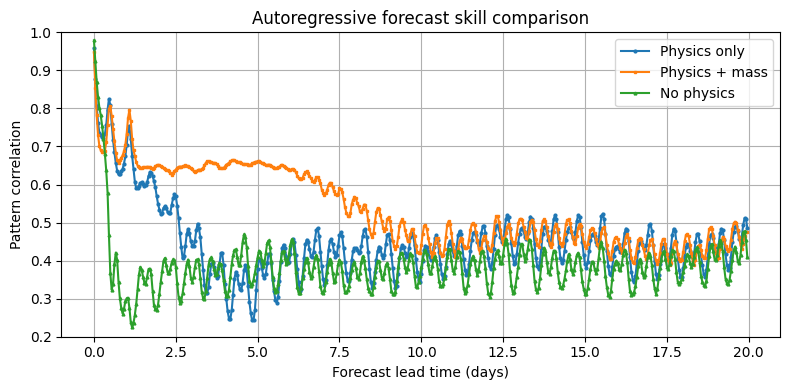

In [4]:
# ============================================
# Step 7: Autoregressive forecast – compare skill
# ============================================
def autoregressive_correlation(model, t_index, n_future_max):
    """
    Autoregressive rollout and pattern correlation vs lead time.
    Returns lead_days, corr_lead.

    Uses normalized fields directly (no un-normalization), which is fine
    because correlation is invariant to linear scaling.
    """
    model.eval()

    # Keep n_future within data range
    if t_index + n_future_max > forcing_tensor.shape[0]:
        n_future = forcing_tensor.shape[0] - t_index
        print(f"Adjusted n_future to {n_future} (data limit).")
    else:
        n_future = n_future_max

    with torch.no_grad():
        # forcing sequence for [t_index, ..., t_index+n_future-1]
        f_seq = forcing_tensor[t_index : t_index + n_future].unsqueeze(0)  # [1,T,2,H,W]
        p0    = prognostic_tensor[t_index].unsqueeze(0)                    # [1,1,H,W]
        pred_seq = model(
            f_seq, p0,
            training=False,
            num_future_steps=n_future
        )  # [T,1,H,W], normalized

    # Use normalized fields directly
    true_seq = target_tensor[t_index : t_index + n_future]   # [T,1,H,W], normalized

    corr_lead = []
    for k in range(n_future):
        t_field = true_seq[k].flatten()
        p_field = pred_seq[k].flatten()

        t_mean = t_field.mean()
        p_mean_loc = p_field.mean()
        num   = torch.sum((t_field - t_mean) * (p_field - p_mean_loc))
        denom = torch.sqrt(torch.sum((t_field - t_mean) ** 2) *
                           torch.sum((p_field - p_mean_loc) ** 2) + 1e-12)
        corr_lead.append((num / denom).item())

    corr_lead = np.array(corr_lead)

    lead_hours = np.arange(n_future)       # 0,1,2,... hours
    lead_days  = lead_hours / 24.0

    return lead_days, corr_lead


# Choose start time in TEST window and forecast horizon
t_index  = n_val
n_future = 480   # ~20 days

lead_days_phys, corr_lead_phys = autoregressive_correlation(
    model_phys, t_index, n_future
)

lead_days_phys_mass, corr_lead_phys_mass = autoregressive_correlation(
    model_phys_mass, t_index, n_future
)

lead_days_nophys, corr_lead_nophys = autoregressive_correlation(
    model_nophys, t_index, n_future
)

# --- Plot comparison ---
plt.figure(figsize=(8, 4))
plt.plot(lead_days_phys, corr_lead_phys,
         marker='o', markersize=2, label="Physics only")
plt.plot(lead_days_phys_mass, corr_lead_phys_mass,
         marker='s', markersize=2, label="Physics + mass")
plt.plot(lead_days_nophys, corr_lead_nophys,
         marker='^', markersize=2, label="No physics")

plt.xlabel("Forecast lead time (days)")
plt.ylabel("Pattern correlation")
plt.ylim(0.2, 1.0)
plt.title("Autoregressive forecast skill comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("autoregressive_pattern_correlation_comparison_with_mass.png")
plt.show()

In [5]:
def autoregressive_mass_error(model, t_index, n_future_max, forcing_tensor,
                              prognostic_tensor, target_tensor,
                              p_mean, p_std, dx, dy, cell_thickness=1.0):
    """
    Compute relative total-mass error vs lead time during autoregressive rollout.
    """
    model.eval()

    if t_index + n_future_max > forcing_tensor.shape[0]:
        n_future = forcing_tensor.shape[0] - t_index
    else:
        n_future = n_future_max

    with torch.no_grad():
        f_seq = forcing_tensor[t_index:t_index+n_future].unsqueeze(0)   # [1,T,2,H,W]
        p0    = prognostic_tensor[t_index].unsqueeze(0)                 # [1,1,H,W]

        pred_seq = model(f_seq, p0, training=False, num_future_steps=n_future)  # [T,1,H,W]
        true_seq = target_tensor[t_index:t_index+n_future]                         # [T,1,H,W]

        # unnormalize
        pred_phys = pred_seq[:, 0] * p_std + p_mean   # [T,H,W]
        true_phys = true_seq[:, 0] * p_std + p_mean   # [T,H,W]

        cell_volume = dx * dy * cell_thickness

        mass_pred = pred_phys.sum(dim=(1, 2)) * cell_volume
        mass_true = true_phys.sum(dim=(1, 2)) * cell_volume

        rel_mass_error = torch.abs(mass_pred - mass_true) / (torch.abs(mass_true) + 1e-12)

    lead_hours = np.arange(n_future)
    lead_days = lead_hours / 24.0

    return lead_days, rel_mass_error.cpu().numpy()

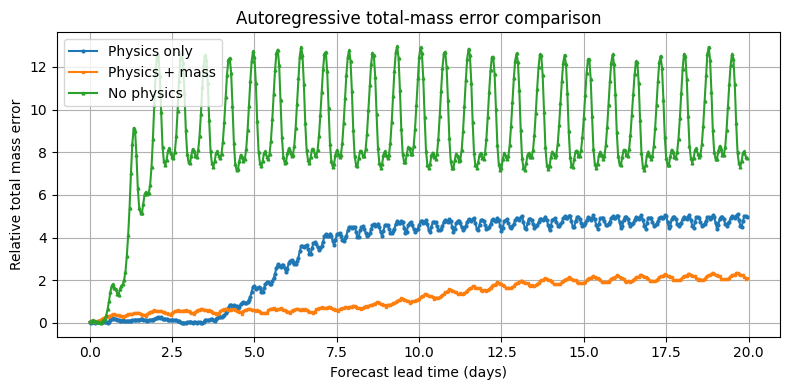

In [6]:
lead_days_me_phys, mass_err_phys = autoregressive_mass_error(
    model_phys, t_index, n_future,
    forcing_tensor, prognostic_tensor, target_tensor,
    p_mean, p_std, dx, dy, cell_thickness=cell_thickness
)

lead_days_me_phys_mass, mass_err_phys_mass = autoregressive_mass_error(
    model_phys_mass, t_index, n_future,
    forcing_tensor, prognostic_tensor, target_tensor,
    p_mean, p_std, dx, dy, cell_thickness=cell_thickness
)

lead_days_me_nophys, mass_err_nophys = autoregressive_mass_error(
    model_nophys, t_index, n_future,
    forcing_tensor, prognostic_tensor, target_tensor,
    p_mean, p_std, dx, dy, cell_thickness=cell_thickness
)

plt.figure(figsize=(8, 4))
plt.plot(lead_days_me_phys, mass_err_phys,
         marker='o', markersize=2, label="Physics only")
plt.plot(lead_days_me_phys_mass, mass_err_phys_mass,
         marker='s', markersize=2, label="Physics + mass")
plt.plot(lead_days_me_nophys, mass_err_nophys,
         marker='^', markersize=2, label="No physics")

plt.xlabel("Forecast lead time (days)")
plt.ylabel("Relative total mass error")
plt.title("Autoregressive total-mass error comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("autoregressive_mass_error_comparison.png")
plt.show()